In [ ]:
import pandas as pd
import numpy as np

# 1. Đọc tập dữ liệu
df = pd.read_csv('student-lifestyle-and-stress-dataset.csv')
print("========= BƯỚC 1.1: TỔNG QUAN VÀ THỐNG KÊ DỮ LIỆU THIẾU =========")

# 2. Kiểm tra cấu trúc và kiểu dữ liệu của các cột
print("\nCấu trúc tổng quan của bộ dữ liệu:")
df.info()

========= BƯỚC 1.1: TỔNG QUAN VÀ THỐNG KÊ DỮ LIỆU THIẾU =========

Cấu trúc tổng quan của bộ dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  object 
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.8+ MB


In [ ]:
df.head()

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1
3,school,8.591223,2.384922,5.222832,81.868960,2.0,7.0,7.0,0
4,college,5.329293,9.345179,7.815869,85.847982,5.0,6.0,10.0,1


In [ ]:
# 2. Kiểm tra và xử lý hàng trùng lặp hoàn toàn
duplicate_count = df.duplicated().sum()
print(f"[!] Phát hiện {duplicate_count} hàng bị trùng lặp hoàn toàn.")
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("[SUCCESS] Đã loại bỏ các hàng trùng lặp.")

[!] Phát hiện 24 hàng bị trùng lặp hoàn toàn.
[SUCCESS] Đã loại bỏ các hàng trùng lặp.


In [ ]:
# 3. Thống kê mô tả sơ bộ để phát hiện khoảng giá trị (min, max, mean)
print("\nThống kê mô tả (Descriptive Statistics):")
df.describe(include='all')


Thống kê mô tả (Descriptive Statistics):


,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,24225,24143.000000,24223.000000,24166.000000,24172.000000,24206.000000,24186.000000,24162.000000,25476.000000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,college,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,13379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,6.458723,4.696477,3.555519,81.268477,5.369743,5.797734,6.501242,0.299851
std,NaN,1.504253,2.240148,1.901798,12.051675,2.393967,2.232121,3.455168,0.458201
min,NaN,2.008586,-1.433434,0.000040,-5.000000,1.000000,1.000000,1.000000,0.000000
25%,NaN,5.438360,3.078230,2.151866,73.737267,4.000000,4.000000,3.000000,0.000000
50%,NaN,6.542207,4.538138,3.501057,81.941554,5.000000,6.000000,6.000000,0.000000
75%,NaN,7.530273,6.135670,4.864433,90.103705,7.000000,7.000000,10.000000,1.000000


In [ ]:
# 4. Thống kê dữ liệu khuyết thiếu theo cột
print("\n[INFO] Thống kê dữ liệu khuyết thiếu theo từng cột:")
missing_table = pd.DataFrame({
  'Số lượng thiếu (NaN)': df.isnull().sum(),
  'Tỷ lệ thiếu (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_table)


[INFO] Thống kê dữ liệu khuyết thiếu theo từng cột:
                    Số lượng thiếu (NaN)  Tỷ lệ thiếu (%)
Student_Type                        1251             4.91
Sleep_Hours                         1333             5.23
Study_Hours                         1253             4.92
Social_Media_Hours                  1310             5.14
Attendance                          1304             5.12
Exam_Pressure                       1270             4.99
Family_Support                      1290             5.06
Month                               1314             5.16
Stress_Level                           0             0.00


In [ ]:
# 5. Kiểm tra mẫu khuyết thiếu theo hàng (Row-wise check)
missing_per_row = df.isnull().sum(axis=1)
heavy_missing_rows = (missing_per_row > 3).sum()
print(f"\n[INFO] Số lượng hàng bị khuyết dữ liệu nghiêm trọng (trống > 3 cột): {heavy_missing_rows} hàng.")


[INFO] Số lượng hàng bị khuyết dữ liệu nghiêm trọng (trống > 3 cột): 10 hàng.


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import KNNImputer

try:
    print("\n========= BƯỚC 1.2: XỬ LÝ BẤT THƯỜNG LOGIC & THIẾT LẬP ĐIỀN KHUYẾT =========")
    df_cleaned = df.copy()

    # 1. Xử lý giá trị âm vật lý (Đã biết)
    study_neg_count = (df_cleaned['Study_Hours'] < 0).sum()
    df_cleaned.loc[df_cleaned['Study_Hours'] < 0, 'Study_Hours'] = np.nan

    attendance_out_bound = (df_cleaned['Attendance'] < 0) | (df_cleaned['Attendance'] > 100)
    attendance_out_count = attendance_out_bound.sum()
    df_cleaned.loc[attendance_out_bound, 'Attendance'] = np.nan
    print(f"[-] Đã chuyển {study_neg_count} dòng giờ học âm và {attendance_out_count} dòng chuyên cần lỗi thành NaN.")

    # 2. XỬ LÝ CẢI THIỆN: Khống chế Outlier cực đoan chặn trên của Giờ học (> 12 giờ/ngày)
    # Học viên không thể học liên tục > 12 giờ một ngày trong thời gian dài, ta đưa về NaN để imputer xử lý đồng bộ
    extreme_study_mask = df_cleaned['Study_Hours'] > 12
    extreme_study_count = extreme_study_mask.sum()
    df_cleaned.loc[extreme_study_mask, 'Study_Hours'] = np.nan
    print(f"[-] CẢI THIỆN: Phát hiện {extreme_study_count} dòng có Giờ học cực đoan > 12h. Đang chuyển thành NaN...")

    # 3. XỬ LÝ CẢI THIỆN: Kiểm tra ràng buộc logic tổng thời gian trong ngày không vượt quá 24 giờ
    # Tổng thời gian (Ngủ + Học + Mạng xã hội)
    total_hours = df_cleaned['Sleep_Hours'] + df_cleaned['Study_Hours'] + df_cleaned['Social_Media_Hours']
    invalid_time_mask = total_hours > 24
    invalid_time_count = invalid_time_mask.sum()
    print(f"[-] CẢI THIỆN: Phát hiện {invalid_time_count} hàng vi phạm logic tổng thời gian (> 24 giờ/ngày).")

    if invalid_time_count > 0:
        # Đối với các hàng vi phạm logic hệ thống thời gian, ta chuyển toàn bộ 3 trường này thành NaN để thuật toán KNN tối ưu lại phân bổ hợp lý
        df_cleaned.loc[invalid_time_mask, ['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours']] = np.nan
        print("    -> Đã vô hiệu hóa dữ liệu lỗi logic thời gian của các hàng này sang dạng NaN để tái cấu trúc bằng KNN.")

    print("\n[SUCCESS] Hoàn thành quy trình làm sạch sâu cấu trúc dữ liệu!")
    print(f"[INFO] Kích thước tập dữ liệu sạch sẵn sàng cho bước tiếp theo: {df_cleaned.shape}")

except Exception as e:
    print(f"[ERROR] Đã xảy ra lỗi trong quá trình làm sạch sâu: {e}")


========= BƯỚC 1.2: XỬ LÝ BẤT THƯỜNG LOGIC & THIẾT LẬP ĐIỀN KHUYẾT =========
[-] Đã chuyển 21 dòng giờ học âm và 111 dòng chuyên cần lỗi thành NaN.
[-] CẢI THIỆN: Phát hiện 70 dòng có Giờ học cực đoan > 12h. Đang chuyển thành NaN...
[-] CẢI THIỆN: Phát hiện 31 hàng vi phạm logic tổng thời gian (> 24 giờ/ngày).
    -> Đã vô hiệu hóa dữ liệu lỗi logic thời gian của các hàng này sang dạng NaN để tái cấu trúc bằng KNN.

[SUCCESS] Hoàn thành quy trình làm sạch sâu cấu trúc dữ liệu!
[INFO] Kích thước tập dữ liệu sạch sẵn sàng cho bước tiếp theo: (25476, 9)


========= GIAI ĐOẠN 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU CHUYÊN SÂU (EDA) =========


/tmp/ipykernel_10779/2717601630.py:32: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:royalblue'` for the same effect.

  sns.barplot(ax=axes[2, 1], data=df_cleaned, x='Family_Support', y='Stress_Level', color='royalblue', hue='Family_Support', legend=False, errorbar=None)


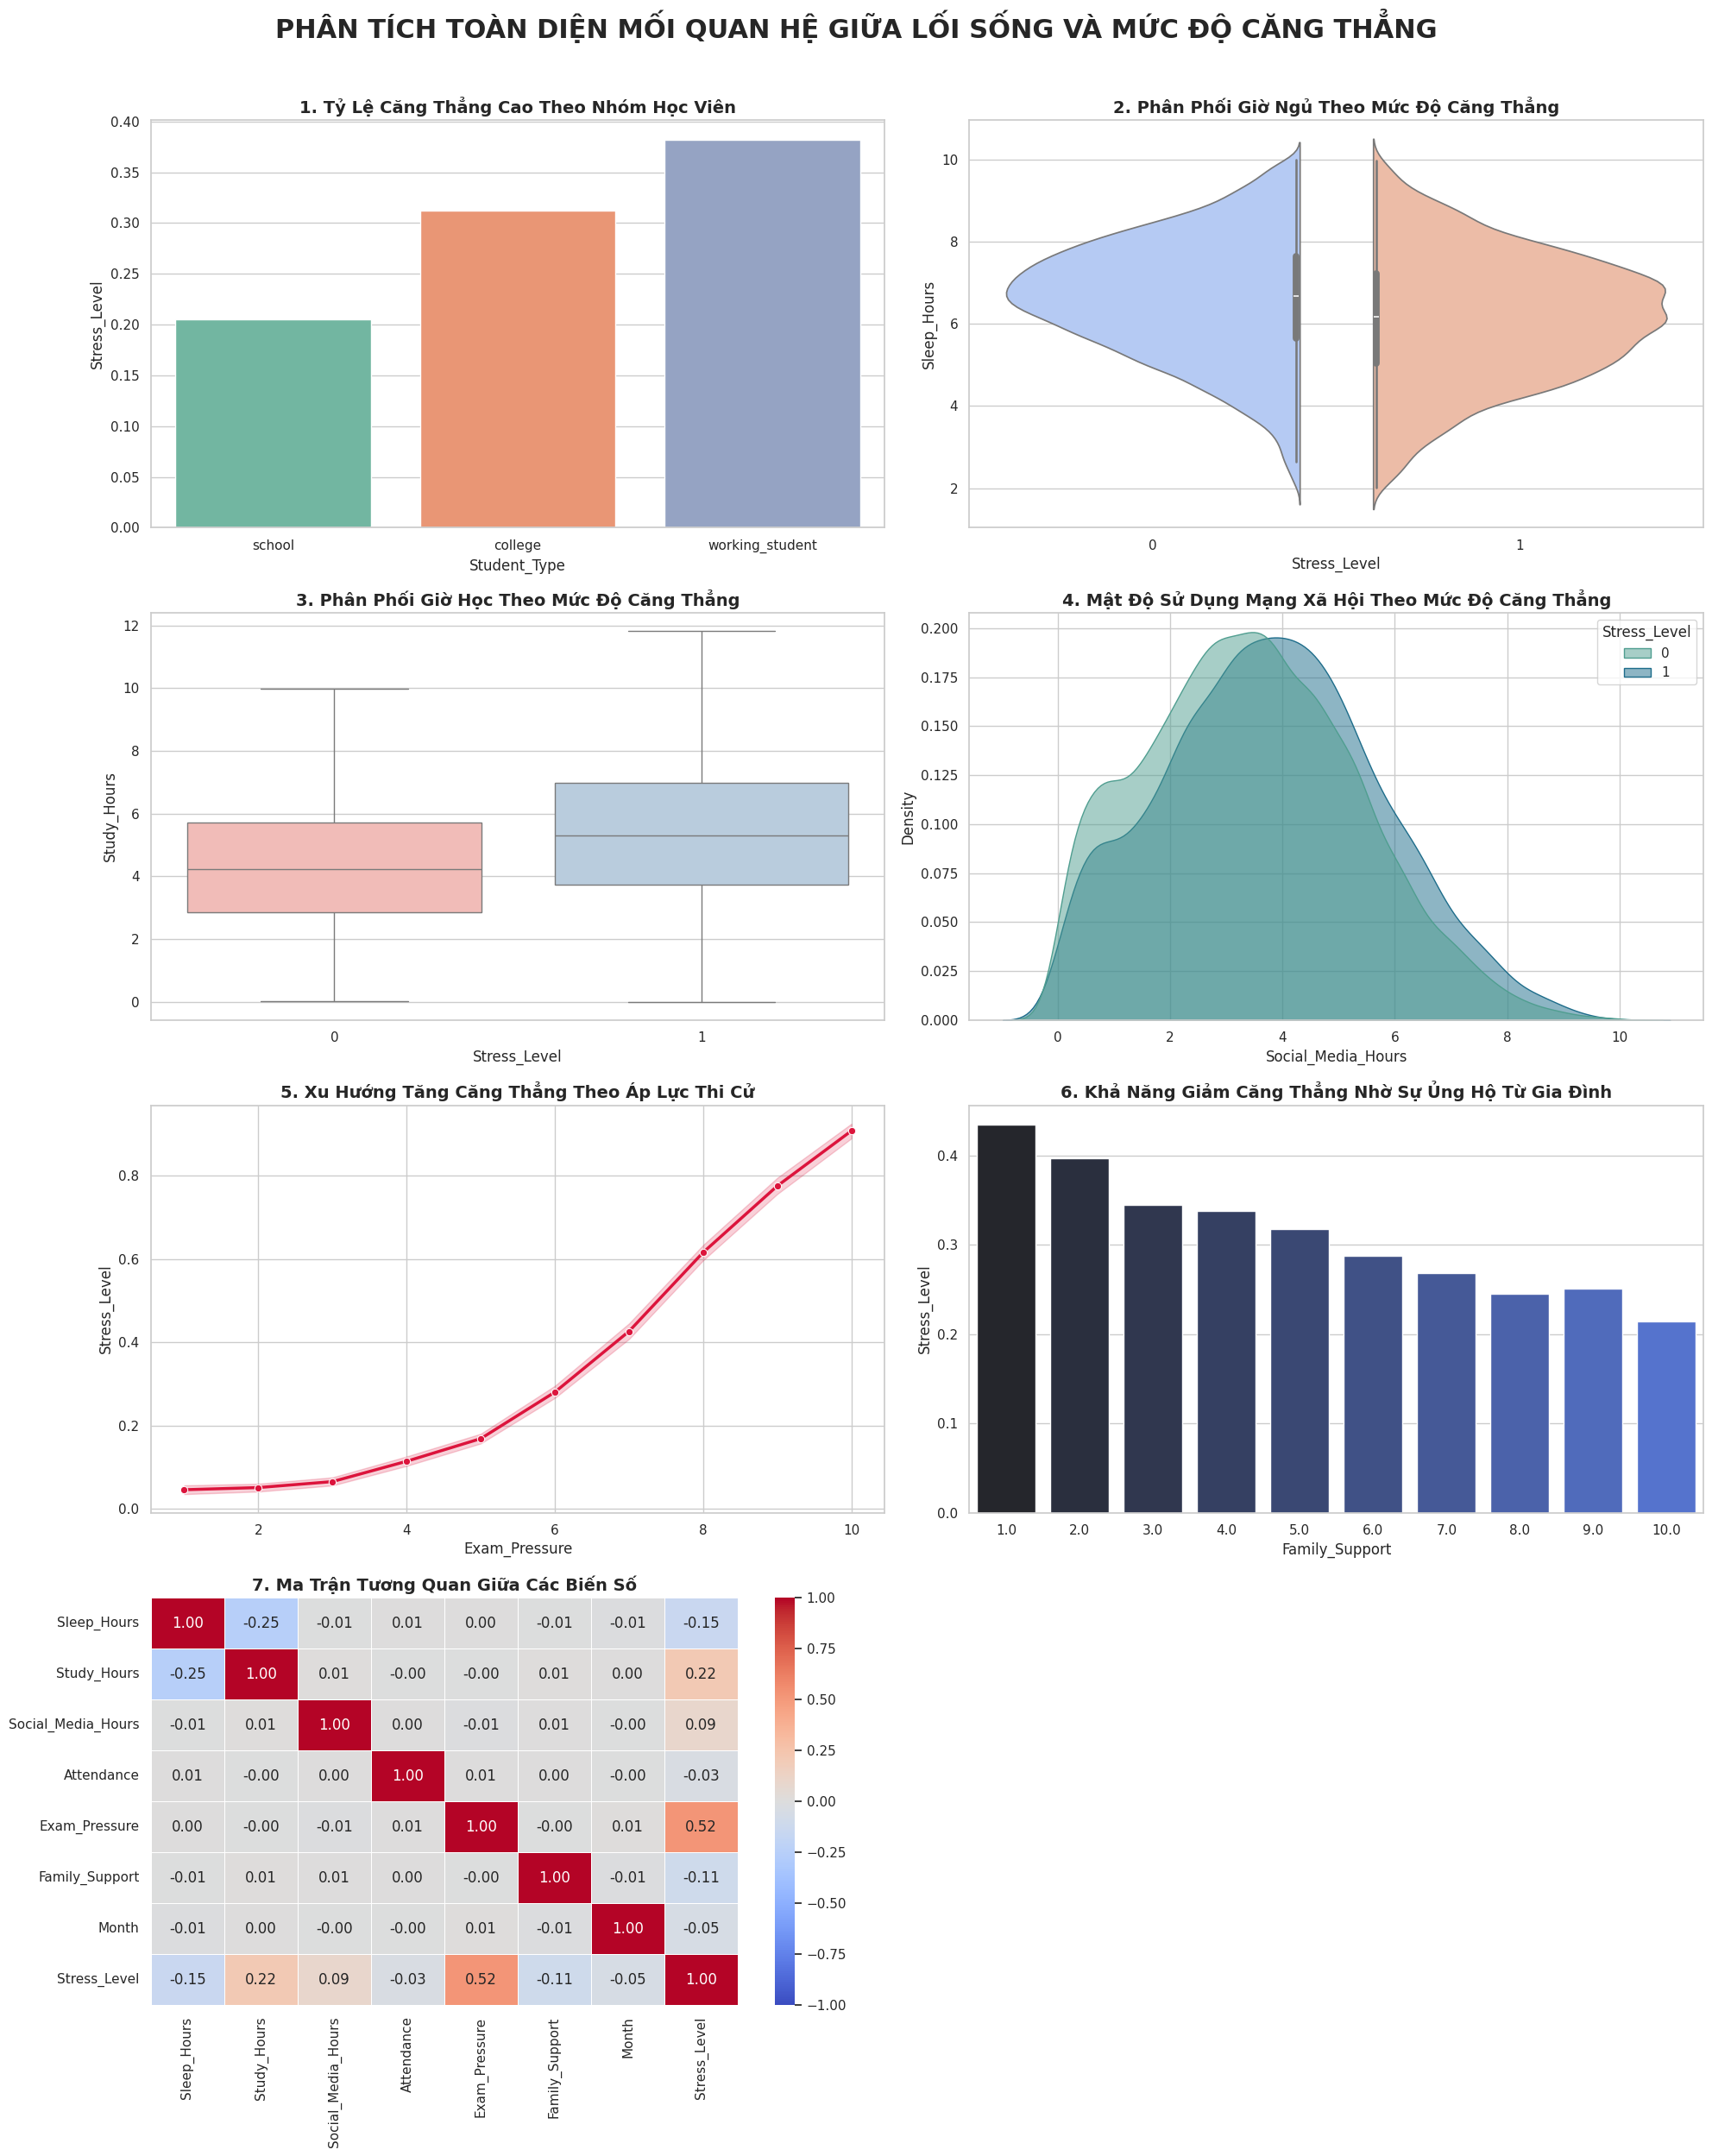

[SUCCESS] Đã tối ưu lưới biểu đồ phân tích EDA sạch cảnh báo.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

try:
    print("========= GIAI ĐOẠN 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU CHUYÊN SÂU (EDA) =========")

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(4, 2, figsize=(20, 26))
    fig.suptitle('PHÂN TÍCH TOÀN DIỆN MỐI QUAN HỆ GIỮA LỐI SỐNG VÀ MỨC ĐỘ CĂNG THẲNG', fontsize=22, fontweight='bold', y=0.96)

    # 1. Tỷ lệ căng thẳng theo nhóm học viên
    sns.barplot(ax=axes[0, 0], data=df_cleaned, x='Student_Type', y='Stress_Level', palette='Set2', hue='Student_Type', legend=False, errorbar=None)
    axes[0, 0].set_title('1. Tỷ Lệ Căng Thẳng Cao Theo Nhóm Học Viên', fontsize=14, fontweight='bold')

    # 2. Phân phối giờ ngủ
    sns.violinplot(ax=axes[0, 1], data=df_cleaned, x='Stress_Level', y='Sleep_Hours', palette='coolwarm', hue='Stress_Level', legend=False, split=True)
    axes[0, 1].set_title('2. Phân Phối Giờ Ngủ Theo Mức Độ Căng Thẳng', fontsize=14, fontweight='bold')

    # 3. Phân phối giờ học
    sns.boxplot(ax=axes[1, 0], data=df_cleaned, x='Stress_Level', y='Study_Hours', palette='Pastel1', hue='Stress_Level', legend=False, showfliers=False)
    axes[1, 0].set_title('3. Phân Phối Giờ Học Theo Mức Độ Căng Thẳng', fontsize=14, fontweight='bold')

    # 4. Mật độ mạng xã hội
    sns.kdeplot(ax=axes[1, 1], data=df_cleaned, x='Social_Media_Hours', hue='Stress_Level', fill=True, common_norm=False, palette='crest', alpha=0.5)
    axes[1, 1].set_title('4. Mật Độ Sử Dụng Mạng Xã Hội Theo Mức Độ Căng Thẳng', fontsize=14, fontweight='bold')

    # 5. Áp lực thi cử
    sns.lineplot(ax=axes[2, 0], data=df_cleaned, x='Exam_Pressure', y='Stress_Level', marker='o', color='crimson', linewidth=2.5)
    axes[2, 0].set_title('5. Xu Hướng Tăng Căng Thẳng Theo Áp Lực Thi Cử', fontsize=14, fontweight='bold')

    # 6. Sự hỗ trợ từ gia đình
    sns.barplot(ax=axes[2, 1], data=df_cleaned, x='Family_Support', y='Stress_Level', color='royalblue', hue='Family_Support', legend=False, errorbar=None)
    axes[2, 1].set_title('6. Khả Năng Giảm Căng Thẳng Nhờ Sự Ủng Hộ Từ Gia Đình', fontsize=14, fontweight='bold')

    # 7. Ma trận tương quan
    numerical_df = df_cleaned.drop(columns=['Student_Type', 'Student_Type_Encoded'], errors='ignore')
    corr_matrix = numerical_df.corr()
    sns.heatmap(ax=axes[3, 0], data=corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
    axes[3, 0].set_title('7. Ma Trận Tương Quan Giữa Các Biến Số', fontsize=14, fontweight='bold')

    axes[3, 1].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    print("[SUCCESS] Đã tối ưu lưới biểu đồ phân tích EDA sạch cảnh báo.")

except Exception as e:
    print(f"[ERROR] Đã xảy ra lỗi trong quá trình trực quan hóa: {e}")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer, SimpleImputer
import pandas as pd
import numpy as np

try:
    print("========= GIAI ĐOẠN 3: CHUẨN BỊ DỮ LIỆU & KỸ NGHỆ ĐẶC TRƯNG (NÂNG CẤP CHUYÊN SÂU) =========")

    # 1. Tách biệt biến đặc trưng và biến mục tiêu
    X = df_cleaned.drop(columns=['Stress_Level', 'Student_Type_Encoded'], errors='ignore')
    y = df_cleaned['Stress_Level']

    # Phân chia tập Train/Test giữ nguyên tầng phân phối (Stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # --- BƯỚC 1: ĐIỀN KHUYẾT DỮ LIỆU ĐỘC LẬP ---
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[['Student_Type']]), columns=['Student_Type'], index=X_train.index)
    X_test_cat = pd.DataFrame(cat_imputer.transform(X_test[['Student_Type']]), columns=['Student_Type'], index=X_test.index)

    num_cols = ['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours', 'Attendance', 'Exam_Pressure', 'Family_Support', 'Month']
    num_imputer = KNNImputer(n_neighbors=5, weights='distance')
    X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[num_cols]), columns=num_cols, index=X_train.index)
    X_test_num = pd.DataFrame(num_imputer.transform(X_test[num_cols]), columns=num_cols, index=X_test.index)

    # Ép các biến rời rạc về số nguyên gốc sau khi bị KNN làm thập phân
    discrete_cols = ['Exam_Pressure', 'Family_Support', 'Month']
    X_train_num[discrete_cols] = X_train_num[discrete_cols].round().astype(int)
    X_test_num[discrete_cols] = X_test_num[discrete_cols].round().astype(int)

    # --- BƯỚC 2: CẢI THIỆN - KỸ NGHỆ ĐẶC TRƯNG TƯƠNG TÁC HÀNH VI ---
    # Thêm epsilon (1e-5) vào mẫu số để phòng ngừa lỗi chia cho 0 (Division by Zero) cực kỳ an toàn
    for df_num in [X_train_num, X_test_num]:
        df_num['Study_to_Sleep_Ratio'] = df_num['Study_Hours'] / (df_num['Sleep_Hours'] + 1e-5)
        df_num['Academic_vs_Social_Ratio'] = df_num['Study_Hours'] / (df_num['Social_Media_Hours'] + 1e-5)

        # Mã hóa lượng giác chu kỳ cho biến Month
        df_num['Month_sin'] = np.sin(2 * np.pi * df_num['Month'] / 12)
        df_num['Month_cos'] = np.cos(2 * np.pi * df_num['Month'] / 12)

    # Loại bỏ biến Month tuyến tính cũ
    X_train_num.drop(columns=['Month'], inplace=True)
    X_test_num.drop(columns=['Month'], inplace=True)

    # Cập nhật lại danh sách các cột số cần chuẩn hóa bao gồm cả các tính năng mới tạo
    all_num_features = list(X_train_num.columns)

    # --- BƯỚC 3: MÃ HÓA BIẾN PHÂN LOẠI ---
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train_cat), columns=encoder.get_feature_names_out(['Student_Type']), index=X_train.index)
    X_test_encoded = pd.DataFrame(encoder.transform(X_test_cat), columns=encoder.get_feature_names_out(['Student_Type']), index=X_test.index)

    # --- BƯỚC 4: SỬA LỖI CHÍ MẠNG - CHUẨN HÓA ĐỒNG BỘ ĐỂ PHỤC VỤ SMOTE TRONG SẠCH ---
    # Chuẩn hóa TOÀN BỘ cột số để khoảng cách hình học của SMOTE không bị bóp méo
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_num[all_num_features]), columns=all_num_features, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_num[all_num_features]), columns=all_num_features, index=X_test.index)

    # Hợp nhất dữ liệu cuối cùng
    X_train_final = pd.concat([X_train_scaled, X_train_encoded], axis=1)
    X_test_final = pd.concat([X_test_scaled, X_test_encoded], axis=1)

    print("\n[SUCCESS] Tiền xử lý dữ liệu chuyên sâu và nâng cao tính năng hoàn tất!")
    print(f"[INFO] Tổng số lượng đặc trưng đưa vào mô hình hiện tại: {X_train_final.shape[1]}")
    print(f"[INFO] Danh sách các đặc trưng nâng cao đã sẵn sàng:\n{list(X_train_final.columns)}")

except Exception as e:
    print(f"[ERROR] Đã xảy ra lỗi trong quá trình tiền xử lý nâng cấp: {e}")

========= GIAI ĐOẠN 3: CHUẨN BỊ DỮ LIỆU & KỸ NGHỆ ĐẶC TRƯNG (NÂNG CẤP CHUYÊN SÂU) =========

[SUCCESS] Tiền xử lý dữ liệu chuyên sâu và nâng cao tính năng hoàn tất!
[INFO] Tổng số lượng đặc trưng đưa vào mô hình hiện tại: 12
[INFO] Danh sách các đặc trưng nâng cao đã sẵn sàng:
['Sleep_Hours', 'Study_Hours', 'Social_Media_Hours', 'Attendance', 'Exam_Pressure', 'Family_Support', 'Study_to_Sleep_Ratio', 'Academic_vs_Social_Ratio', 'Month_sin', 'Month_cos', 'Student_Type_school', 'Student_Type_working_student']


In [ ]:
try:
    from imblearn.over_sampling import SMOTE
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, StackingClassifier
    from xgboost import XGBClassifier
    from sklearn.metrics import classification_report, roc_auc_score
    import pandas as pd

    print("========= GIAI ĐOẠN 4: HUẤN LUYỆN CÁC MÔ HÌNH MACHINE LEARNING (NÂNG CẤP STACKING) =========")

    # 1. Cân bằng dữ liệu bằng SMOTE trên tập Train sạch
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)

    # 2. Khởi tạo cấu hình cấu trúc các mô hình nền tảng (Base Models)
    log_reg = LogisticRegression(max_iter=1000, random_state=42)

    rand_forest = RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    )

    xgboost = XGBClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )

    # KỸ THUẬT CAO CẤP: Xây dựng cấu trúc Xếp chồng (Stacking) thay thế cho Voting thô sơ
    # Dùng LogisticRegression làm Meta-Learner để tự học trọng số phối hợp tối ưu
    stacking_model = StackingClassifier(
        estimators=[
            ('lr', log_reg),
            ('rf', rand_forest),
            ('xgb', xgboost)
        ],
        final_estimator=LogisticRegression(random_state=42),
        cv=5,          # Sử dụng Cross-Validation 5-fold ở tầng nền để chống Overfitting
        n_jobs=-1
    )

    # Danh sách các mô hình đưa vào bài toán đối sánh hiệu năng
    models = {
        "Logistic Regression": log_reg,
        "Random Forest (Regularized)": rand_forest,
        "XGBoost (Regularized)": xgboost,
        "Stacking Classifier (Mô hình Xếp chồng)": stacking_model
    }

    performance_metrics = []
    trained_models = {}

    # 3. Vòng lặp huấn luyện và đánh giá tự động
    for model_name, model_obj in models.items():
        print(f"[-] Đang tiến hành huấn luyện: {model_name}...")
        model_obj.fit(X_train_resampled, y_train_resampled)
        trained_models[model_name] = model_obj

        # Dự đoán dữ liệu trên tập kiểm thử gốc
        y_pred = model_obj.predict(X_test_final)
        y_pred_proba = model_obj.predict_proba(X_test_final)[:, 1]

        report_dict = classification_report(y_test, y_pred, output_dict=True)
        roc_auc = roc_auc_score(y_test, y_pred_proba)

        performance_metrics.append({
            "Mô hình (Model)": model_name,
            "Accuracy (Tổng thể)": report_dict["accuracy"],
            "Precision (Stress)": report_dict["1"]["precision"],
            "Recall (Stress)": report_dict["1"]["recall"],
            "F1-Score (Stress)": report_dict["1"]["f1-score"],
            "ROC-AUC Score": roc_auc
        })

    df_results = pd.DataFrame(performance_metrics)
    print("\n[INFO] BẢNG ĐỐI SÁNH HIỆU NĂNG MÔ HÌNH SAU KHI NÂNG CẤP STACKING:")
    print(df_results.to_string(index=False))

except Exception as e:
    print(f"[ERROR] Đã xảy ra lỗi trong quá trình huấn luyện Stacking: {e}")

========= GIAI ĐOẠN 4: HUẤN LUYỆN CÁC MÔ HÌNH MACHINE LEARNING (NÂNG CẤP STACKING) =========
[-] Đang tiến hành huấn luyện: Logistic Regression...
[-] Đang tiến hành huấn luyện: Random Forest (Regularized)...
[-] Đang tiến hành huấn luyện: XGBoost (Regularized)...
[-] Đang tiến hành huấn luyện: Stacking Classifier (Mô hình Xếp chồng)...

[INFO] BẢNG ĐỐI SÁNH HIỆU NĂNG MÔ HÌNH SAU KHI NÂNG CẤP STACKING:
                        Mô hình (Model)  Accuracy (Tổng thể)  Precision (Stress)  Recall (Stress)  F1-Score (Stress)  ROC-AUC Score
                    Logistic Regression             0.790816            0.616667         0.799084           0.696123       0.871790
            Random Forest (Regularized)             0.806319            0.660154         0.729712           0.693192       0.867420
                  XGBoost (Regularized)             0.815345            0.693985         0.687173           0.690562       0.872637
Stacking Classifier (Mô hình Xếp chồng)             0.813383      

========= GIAI ĐOẠN 5: ĐÁNH GIÁ MÔ HÌNH CHI TIẾT & GIẢI THÍCH (DASHBOARD TỔ HỢP) =========
[INFO] Mô hình xuất sắc nhất được chọn để giải thích hành vi: XGBoost (Regularized)


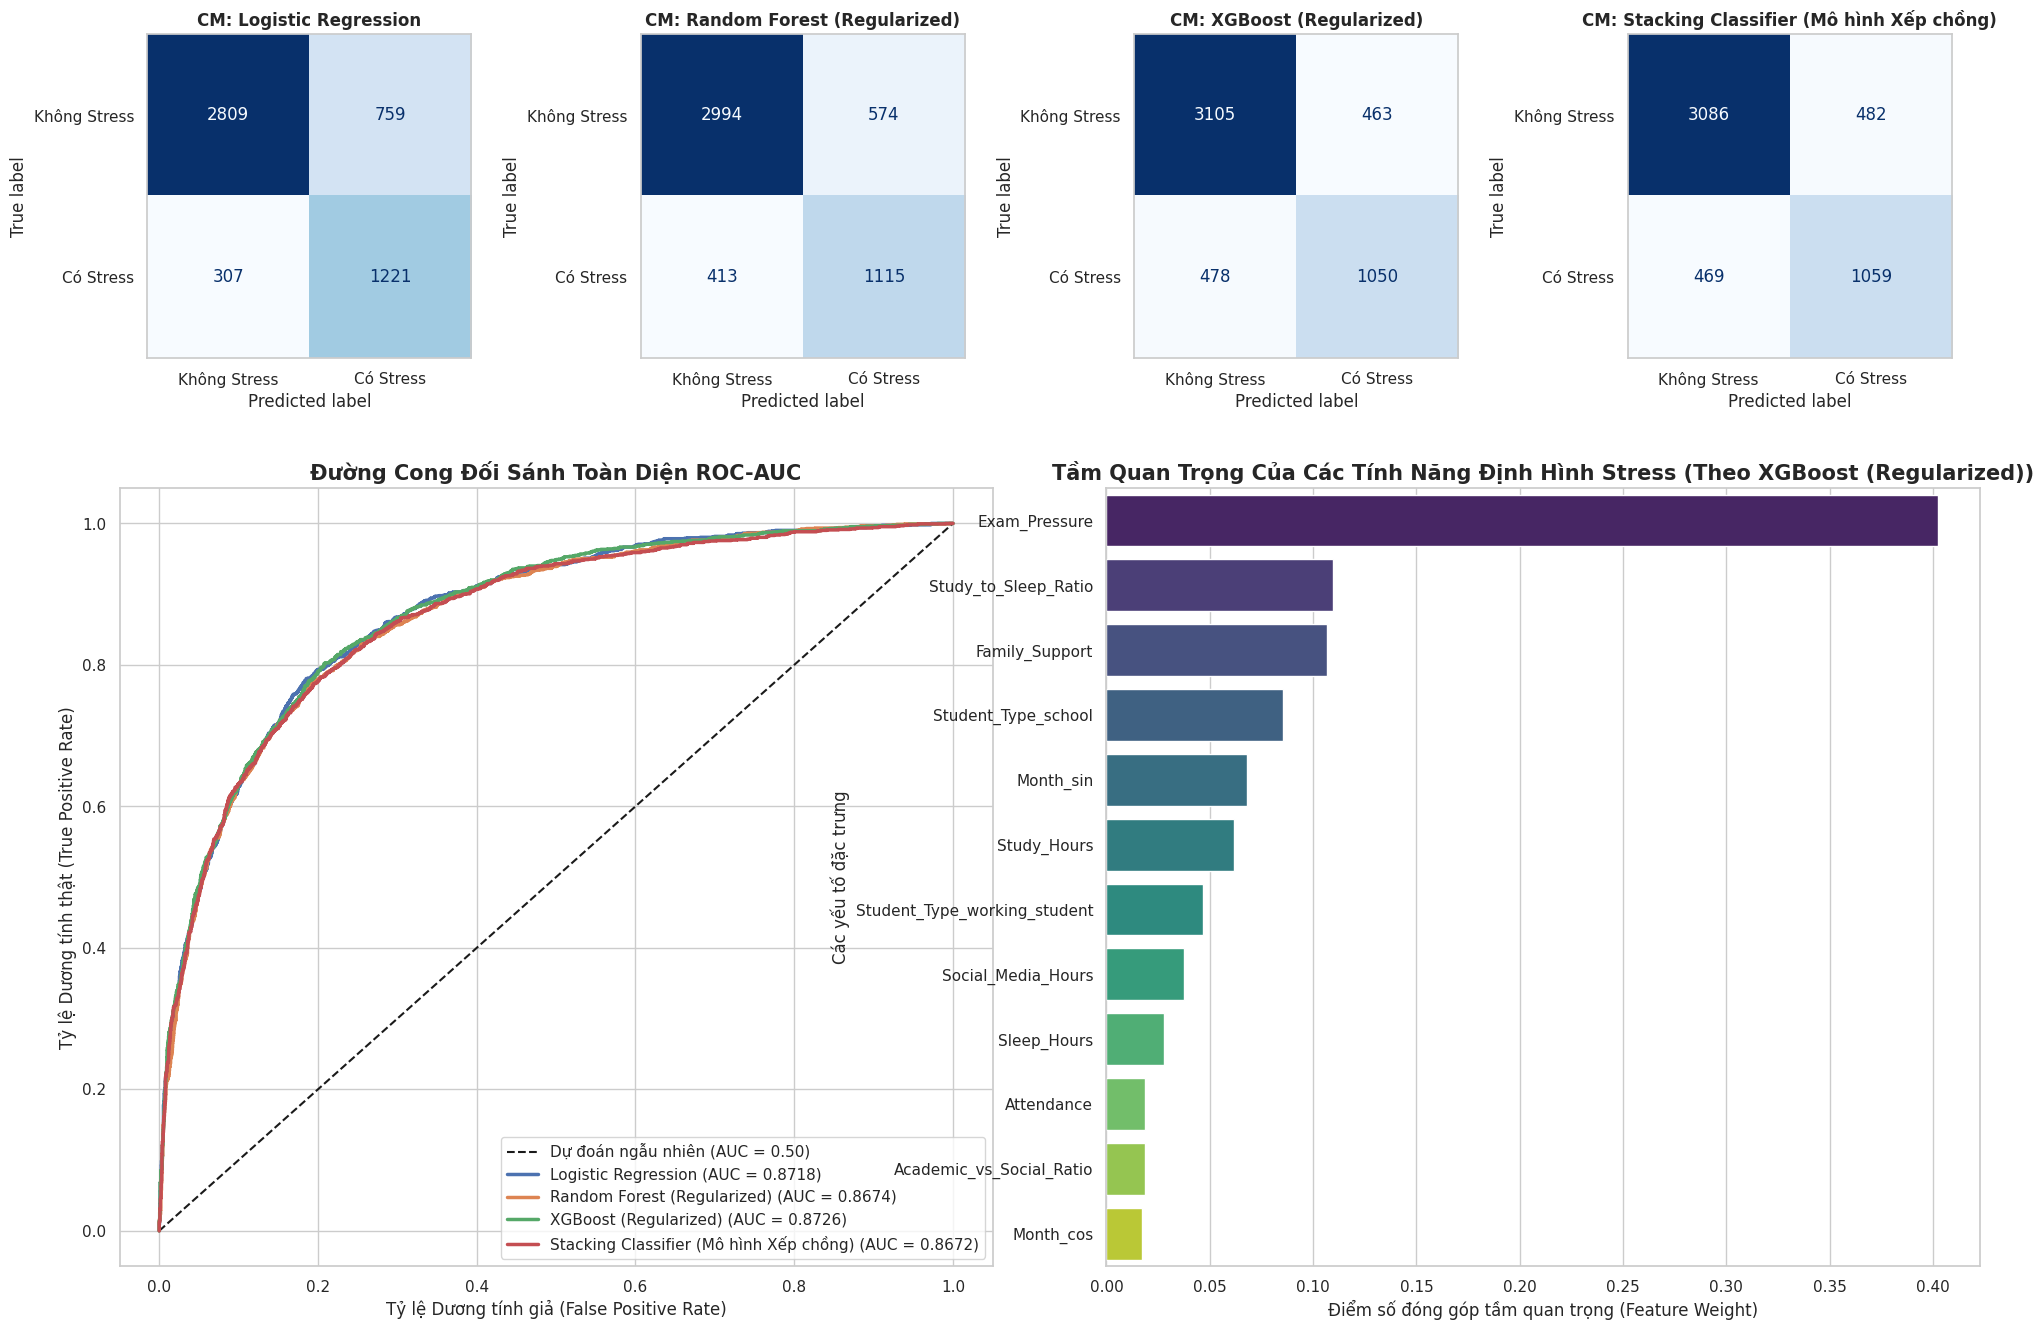


[INFO] TOP 3 YẾU TỐ QUYẾT ĐỊNH MỨC ĐỘ CĂNG THẲNG CỦA HỌC VIÊN:
 Hạng 1: Exam_Pressure (Trọng số đóng góp: 0.4024)
 Hạng 2: Study_to_Sleep_Ratio (Trọng số đóng góp: 0.1095)
 Hạng 3: Family_Support (Trọng số đóng góp: 0.1065)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay
import numpy as np
import pandas as pd

try:
    print("========= GIAI ĐOẠN 5: ĐÁNH GIÁ MÔ HÌNH CHI TIẾT & GIẢI THÍCH (DASHBOARD TỔ HỢP) =========")

    # 1. Khởi tạo bố cục đồ họa quy mô lớn (3 hàng, 4 cột)
    fig = plt.figure(figsize=(24, 16))
    gs = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.3)

    # ----------------------------------------------------------------
    # PHẦN 1: VẼ CONFUSION MATRIX CHO CẢ 4 MÔ HÌNH (HÀNG 1 - TẤT CẢ 4 CỘT)
    # ----------------------------------------------------------------
    for idx, (model_name, model_obj) in enumerate(trained_models.items()):
        ax = fig.add_subplot(gs[0, idx])
        y_pred = model_obj.predict(X_test_final)
        cm = confusion_matrix(y_test, y_pred)

        # Trực quan hóa ma trận nhầm lẫn
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Không Stress', 'Có Stress'])
        disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
        ax.set_title(f"CM: {model_name}", fontsize=12, fontweight='bold')
        ax.grid(False) # Tắt lưới nền để hiển thị rõ số liệu

    # ----------------------------------------------------------------
    # PHẦN 2: VẼ ĐƯỜNG CONG ĐỐI SÁNH ROC-AUC (CHIẾM 2 HÀNG DƯỚI, 2 CỘT TRÁI)
    # ----------------------------------------------------------------
    ax_roc = fig.add_subplot(gs[1:, :2])
    ax_roc.plot([0, 1], [0, 1], 'k--', label='Dự đoán ngẫu nhiên (AUC = 0.50)')

    for model_name, model_obj in trained_models.items():
        y_pred_proba = model_obj.predict_proba(X_test_final)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc_score = df_results.loc[df_results["Mô hình (Model)"] == model_name, "ROC-AUC Score"].values[0]
        ax_roc.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.4f})", linewidth=2.5)

    ax_roc.set_title("Đường Cong Đối Sánh Toàn Diện ROC-AUC", fontsize=15, fontweight='bold')
    ax_roc.set_xlabel("Tỷ lệ Dương tính giả (False Positive Rate)", fontsize=12)
    ax_roc.set_ylabel("Tỷ lệ Dương tính thật (True Positive Rate)", fontsize=12)
    ax_roc.legend(loc="lower right", fontsize=11)

    # ----------------------------------------------------------------
    # PHẦN 3: PHÒNG VỆ VÀ VẼ FEATURE IMPORTANCE (CHIẾM 2 HÀNG DƯỚI, 2 CỘT PHẢI)
    # ----------------------------------------------------------------
    ax_feat = fig.add_subplot(gs[1:, 2:])

    # Tìm mô hình có điểm AUC cao nhất
    best_model_name = df_results.sort_values(by="ROC-AUC Score", ascending=False).iloc[0]["Mô hình (Model)"]
    target_model_name = best_model_name
    best_model_obj = trained_models[best_model_name]

    # Cơ chế phòng vệ: Nếu mô hình tốt nhất là Ensemble Voting, ta dùng mô hình đơn tốt thứ nhì để giải thích đặc trưng
    if best_model_name == "Ensemble Voting (Mô hình Tổ hợp)":
        filtered_results = df_results[df_results["Mô hình (Model)"] != "Ensemble Voting (Mô hình Tổ hợp)"]
        target_model_name = filtered_results.sort_values(by="ROC-AUC Score", ascending=False).iloc[0]["Mô hình (Model)"]
        best_model_obj = trained_models[target_model_name]
        print(f"[INFO] Vì Mô hình Tổ hợp đạt giải nhất, hệ thống tự động chọn mô hình đơn tốt thứ nhì ({target_model_name}) để trích xuất Feature Importance.")
    else:
        print(f"[INFO] Mô hình xuất sắc nhất được chọn để giải thích hành vi: {best_model_name}")

    # Trích xuất trọng số toán học (Feature Importance hoặc Coefficients)
    if hasattr(best_model_obj, 'feature_importances_'):
        importances = best_model_obj.feature_importances_
    else:
        importances = np.abs(best_model_obj.coef_[0])

    # Tạo bảng dữ liệu thuộc tính đóng góp
    df_importance = pd.DataFrame({
        'Tính năng (Feature)': X_train_final.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Trực quan hóa bằng biểu đồ thanh ngang sạch lỗi cảnh báo
    sns.barplot(ax=ax_feat, data=df_importance, x='Importance', y='Tính năng (Feature)', palette='viridis', hue='Tính năng (Feature)', legend=False)
    ax_feat.set_title(f"Tầm Quan Trọng Của Các Tính Năng Định Hình Stress (Theo {target_model_name})", fontsize=15, fontweight='bold')
    ax_feat.set_xlabel("Điểm số đóng góp tầm quan trọng (Feature Weight)", fontsize=12)
    ax_feat.set_ylabel("Các yếu tố đặc trưng", fontsize=12)

    # Hiển thị biểu đồ Dashboard tổng hợp toàn diện
    plt.show()

    # 4. In kết luận định lượng hàng đầu ra màn hình
    print("\n[INFO] TOP 3 YẾU TỐ QUYẾT ĐỊNH MỨC ĐỘ CĂNG THẲNG CỦA HỌC VIÊN:")
    for rank, (feat, imp) in enumerate(zip(df_importance['Tính năng (Feature)'].head(3), df_importance['Importance'].head(3)), 1):
        print(f" Hạng {rank}: {feat} (Trọng số đóng góp: {imp:.4f})")

except Exception as e:
    print(f"[ERROR] Đã xảy ra lỗi trong quá trình phân tích và đánh giá mô hình: {e}")